# Lesson 2.8 — Boundary Conditions

## The Constraint That Defines the Problem

The N-S equations have infinitely many solutions — a specific flow is selected by the
boundary conditions. Two different BC choices on the same geometry give entirely different
physical flows. Getting BCs right is as important as getting the equations right.

---

## Types of Boundary Conditions

### Dirichlet (Essential): Prescribed Value

$$\phi|_{\text{boundary}} = \phi_0$$

Examples: no-slip wall ($\mathbf{u}=0$), moving lid ($u=U$), prescribed inlet velocity.

Implementation: set the boundary cell/node directly. In 2D:
```python
u[0, :] = 0.0    # bottom wall: u=0
u[-1, :] = 1.0   # top lid: u=1
```

### Neumann (Natural): Prescribed Gradient

$$\frac{\partial \phi}{\partial n}\bigg|_{\text{boundary}} = g$$

Most common: zero-gradient ($g=0$), meaning the field extrapolates smoothly out of the domain.
Used for: outlet velocity, pressure at walls.

Implementation using a ghost cell:
```python
u[:, -1] = u[:, -2]    # outflow: du/dx=0 (zero-gradient)
p[0, :]  = p[1, :]     # wall: dp/dy=0 (no pressure flux)
```

### Periodic: Domain Wraps Around

$$\phi(x=0) = \phi(x=L)$$

Used for infinite channels, turbulence simulations, and any flow with translational symmetry.

Implementation:
```python
u[:, 0] = u[:, -2]   # left = right (periodic in x)
u[:, -1] = u[:, 1]
```

---

## Ghost Cells — The Universal BC Trick

A **ghost cell** is a fictitious cell outside the domain boundary. By assigning it the
right value, you can apply any BC using the same interior stencil — no special-casing needed.

```
Domain:     | ghost |  i=0  |  i=1  |  i=2  | ... | ghost |
                 ↑                                      ↑
               i=-1 (ghost)                         i=N (ghost)
```

For zero-Neumann at left boundary ($\partial u/\partial x = 0$):
$$u_{-1} = u_1 \quad \Rightarrow \quad \text{central diff: } \frac{u_1 - u_{-1}}{2\Delta x} = 0 \checkmark$$

For prescribed flux $\partial u/\partial x = g$ at left:
$$u_{-1} = u_1 - 2\Delta x \cdot g$$

---

## Pressure BCs — The Subtle Part

Pressure in incompressible flow is determined only up to an additive constant.
You must **pin** the pressure somewhere:

- Fix $p = 0$ at one point (usually a corner)
- Or remove the mean: `p -= p.mean()`
- Or use a Dirichlet BC at inlet/outlet

Without this, the PPE is singular (the all-constants vector is in the null space).

---

## Inlet and Outlet BCs

| Boundary | Variable | Typical BC |
|----------|----------|------------|
| Inlet | $u$ | Dirichlet (prescribed profile) |
| Inlet | $p$ | Neumann $\partial p/\partial n = 0$ |
| Outlet | $u$ | Neumann $\partial u/\partial n = 0$ (convective or zero-gradient) |
| Outlet | $p$ | Dirichlet $p = 0$ |
| Wall (no-slip) | $u, v$ | Dirichlet $= 0$ |
| Wall | $p$ | Neumann $\partial p/\partial n = 0$ |

Getting the **pressure BC at walls** wrong is one of the most common bugs in CFD code.


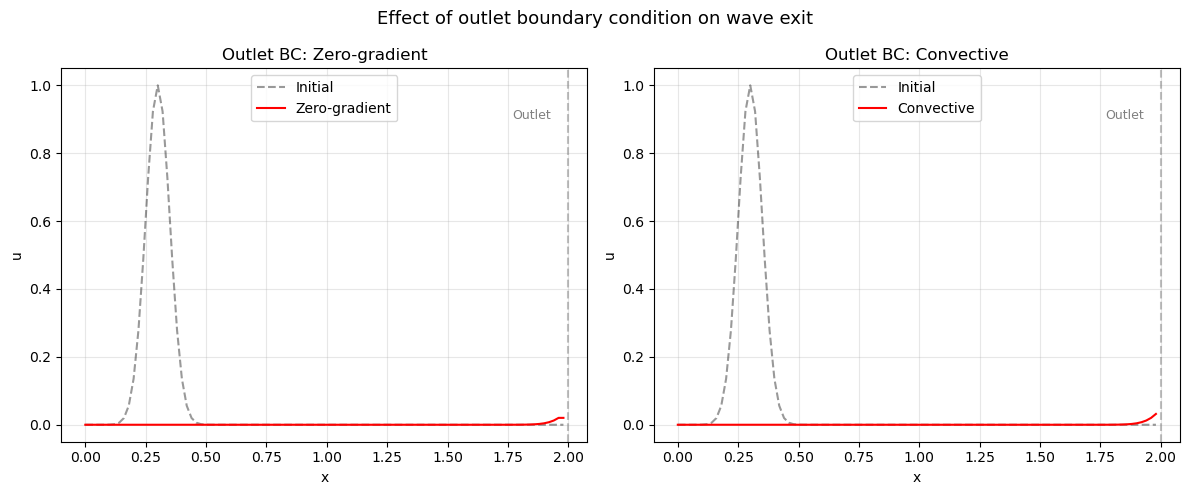

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate different outlet BCs for 1D advection
# Problem: pulse propagating through a channel, exits at x=L
# Compare: zero-gradient, convective, reflective

N = 100
L = 2.0
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)
c  = 1.0
dt = 0.8 * dx / c
nt = 120

# Initial: Gaussian pulse in left half
u0 = np.exp(-((x - 0.3)**2) / 0.005)

def advect_with_bc(u0, bc='zero_gradient'):
    u = u0.copy()
    for _ in range(nt):
        u_old = u.copy()
        # Interior: upwind
        u[1:-1] = u_old[1:-1] - c*dt/dx*(u_old[1:-1] - u_old[:-2])
        # Left inlet: Dirichlet u=0 (no more pulse coming in)
        u[0] = 0.0
        # Right outlet BCs
        if bc == 'zero_gradient':
            u[-1] = u[-2]                        # du/dx = 0
        elif bc == 'convective':
            u[-1] = u_old[-1] - c*dt/dx*(u_old[-1] - u_old[-2])  # advect out
        elif bc == 'reflective':
            u[-1] = u[-2]                        # same as zero-gradient but represents a wall
            # Reinject reflected wave
            u[-1] = u_old[-1] + c*dt/dx*(u_old[-1] - u_old[-2])  # inward wave
    return u

# Exact: just translates off the right side
x_exact = x - c*nt*dt
u_exact = np.exp(-((x_exact - 0.3)**2) / 0.005)  # zero outside domain

u_zg  = advect_with_bc(u0, 'zero_gradient')
u_con = advect_with_bc(u0, 'convective')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, u_num, label in zip(axes, [u_zg, u_con], ['Zero-gradient', 'Convective']):
    ax.plot(x, u0,     'k--', alpha=0.4, label='Initial')
    ax.plot(x, u_num,  'r-',  linewidth=1.5, label=label)
    ax.set_title(f'Outlet BC: {label}')
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.axvline(L, color='gray', linestyle='--', alpha=0.5)
    ax.text(1.85, 0.9, 'Outlet', ha='center', fontsize=9, color='gray')

plt.suptitle('Effect of outlet boundary condition on wave exit', fontsize=13)
plt.tight_layout()
plt.show()

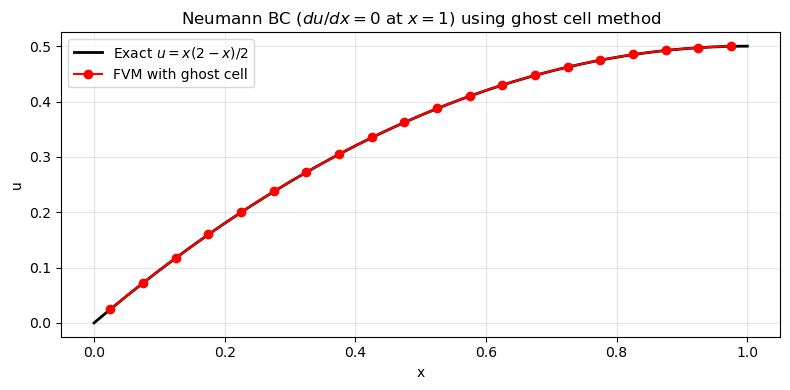

Max error: 3.1250e-04
Slope at outlet (should be ~0): 0.0500


In [2]:
# Ghost cell demonstration for Neumann BC
# Solve -d²u/dx² = 1 with u(0)=0 (Dirichlet) and du/dx(1)=0 (Neumann)

N = 20
dx = 1.0 / N
x_cells = np.linspace(0.5*dx, 1.0 - 0.5*dx, N)

# Extend grid with one ghost cell on the right
# Ghost cell at index N has value u[N] = u[N-1] (zero gradient)

# Build system including ghost cell
Ng = N + 1  # N interior + 1 ghost
A = np.zeros((N, Ng))
b = np.ones(N) * dx**2  # RHS = S * dx^2

for i in range(N):
    A[i, i+1] = -1  # right neighbour
    A[i, i]   =  2  # self (but first cell has special treatment)
    if i > 0:
        A[i, i-1] = -1  # left neighbour
    else:
        b[0] += 0.0  # u_left_ghost = -u[0] (antisymmetric for u(0)=0)

# Apply ghost cell BC: u[N] = u[N-1] (zero Neumann)
# This means: A[N-1, N] = -1, but u[N] = u[N-1], so add column N contribution to column N-1
A[N-1, N-1] += -1  # absorb ghost: -u[N] = -u[N-1] added to diagonal
A_reduced = A[:, :N]

# Dirichlet at left: u(-1) = -u[0] → adds 1 to diagonal of first row
A_reduced[0, 0] += 1

u_num = np.linalg.solve(A_reduced, b)

# Exact: -d²u/dx² = 1, u(0)=0, u'(1)=0 → u = x(2-x)/2 → at x=1: u=1/2, u'=0
u_exact = x_cells * (2 - x_cells) / 2

plt.figure(figsize=(8, 4))
x_fine = np.linspace(0, 1, 200)
plt.plot(x_fine, x_fine*(2-x_fine)/2, 'k-', linewidth=2, label='Exact $u = x(2-x)/2$')
plt.plot(x_cells, u_num, 'ro-', markersize=6, label='FVM with ghost cell')
plt.xlabel('x'); plt.ylabel('u')
plt.title('Neumann BC ($du/dx=0$ at $x=1$) using ghost cell method')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max error: {np.max(np.abs(u_num - u_exact)):.4e}")
print(f"Slope at outlet (should be ~0): {(u_num[-1] - u_num[-2])/dx:.4f}")

## Key Takeaways

- BCs define the problem — wrong BCs give physically incorrect results even if the solver is perfect.
- **Dirichlet** (prescribed value): walls, inlets. Set boundary array values directly.
- **Neumann** (prescribed gradient): outlets, pressure walls. Use ghost cells.
- **Periodic**: translational symmetry. Wrap last row/column to first.
- Pressure must be pinned at one point in incompressible flow — otherwise the PPE is singular.
- Outlet BCs matter: convective (non-reflecting) BCs prevent waves from bouncing back.

---

**End of Module 2.** You now have a working N-S solver and understand the full incompressible CFD pipeline.

**Next**: Module 3, Lesson 1 — Turbulence Basics: Reynolds decomposition, RANS, the closure problem.
